# 資料準備

## 下載資料集

In [1]:
# > 執行下載腳本 (會自動檢查檔案是否已存在)
from scripts.download_data import download_and_sample_data
download_and_sample_data()

# @ 讀取並預覽資料
import pandas as pd
df = pd.read_csv("data/songs.csv")
df.head()


d:\台北市立大學 資訊科學系 在職專班\碩一\上學期\資料探勘\final_spotify\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


// @ 偵測到資料集已存在於 data/songs.csv，跳過下載步驟。


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,113186,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50,440247,False,0.369,0.598,...,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,42819,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11,93933,False,0.171,0.997,...,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,59311,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0,213578,False,0.173,0.803,...,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,91368,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0,151387,False,0.683,0.511,...,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,61000,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,57,236293,False,0.555,0.941,...,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


## 數值特徵處理

In [2]:
# > 呼叫模組化前處理腳本
from scripts.data_processing import preprocess_pipeline

df_processed = preprocess_pipeline(df, save_path="data/processed_songs.csv")
df_processed.head()

// @ 找到已處理過的資料檔案: data/processed_songs.csv，直接讀取...


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness_scaled,instrumentalness_binary,key_sin,key_cos,mode_scaled,time_signature_orig,time_signature_1,time_signature_3,time_signature_4,time_signature_5
0,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50,440247,0,0.369,0.598,7,...,0.164554,0,-5.000000e-01,-8.660254e-01,0.756145,4,False,False,True,False
1,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11,93933,0,0.171,0.997,7,...,0.411944,1,-5.000000e-01,-8.660254e-01,0.756145,4,False,False,True,False
2,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0,213578,0,0.173,0.803,9,...,0.183818,0,-1.000000e+00,-1.836970e-16,-1.322497,3,False,True,False,False
3,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0,151387,0,0.683,0.511,6,...,0.098652,0,1.224647e-16,-1.000000e+00,0.756145,3,False,True,False,False
4,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,57,236293,0,0.555,0.941,9,...,0.255805,0,-1.000000e+00,-1.836970e-16,-1.322497,4,False,False,True,False


## PCA降維

In [3]:
# > 呼叫 PCA 降維腳本
from scripts.dimension_reduction import apply_pca

df_pca = apply_pca(df_processed, save_path="data/pca_songs.csv")
df_pca.head()


// @ 找到已處理過的 PCA 資料檔: data/pca_songs.csv，直接讀取...


,track_id,track_name,artists,album_name,track_genre,popularity,explicit,PC_1,PC_2,PC_3,...,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15,PC_16,PC_17,PC_18
0,6KwkVtXm8OUp2XffN5k7lY,No Other Name,Hillsong Worship,No Other Name,world-music,50,0,-0.674731,-2.685279,-0.359900,...,-0.286668,0.210928,0.408437,-0.183881,-0.056847,-0.245421,0.065196,-0.010004,-1.776357e-15,-4.440892e-16
1,2dp5I5MJ8bQQHDoFaNRFtX,Failed Organum,Internal Rot,Grieving Birth,grindcore,11,0,-0.181294,-1.446805,2.717891,...,-0.413345,-0.582913,-0.081323,0.665448,-0.091810,0.011971,0.130111,0.045460,0.000000e+00,2.220446e-16
2,5avw06usmFkFrPjX8NxC40,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,iranian,0,0,-1.471017,-1.461071,0.705508,...,-0.795367,0.687363,-1.087552,-0.361745,0.281921,0.249054,-0.296122,0.194167,1.887379e-15,7.771561e-16
3,75hT0hvlESnDJstem0JgyR,Merry Christmas,Bryan Adams,All I Want For Christmas Is You,rock,0,0,-0.047866,1.105693,-0.111528,...,0.300422,1.328159,-1.071729,0.128981,0.341667,-0.104748,0.020137,0.142053,0.000000e+00,0.000000e+00
4,4bY2oZGA5Br3pTE1Jd1IfY,月の大きさ,Nogizaka46,バレッタ TypeD,j-idol,57,0,1.549024,0.127960,-1.138278,...,-0.652978,0.111592,0.041133,0.084028,-0.011768,0.366896,-0.148550,0.000588,2.442491e-15,5.551115e-16


## [DATA 1] 計算偽共現關係

In [4]:
# > 呼叫相似度矩陣計算腳本 (偽共現關係)
from scripts.similarity_matrix import calculate_similarity_matrix

# 計算每首歌最相似的前 10 首
all_similar_songs = calculate_similarity_matrix(df_pca, n_top=10, save_path="data/precomputed_similar_songs.json")

# 預覽第一首歌的相似結果
import json
print(json.dumps(all_similar_songs[0], indent=2, ensure_ascii=False))


// @ 找到預先計算的相似歌曲檔案: data/precomputed_similar_songs.json，直接載入...
{
  "track_id": "6KwkVtXm8OUp2XffN5k7lY",
  "track_name": "No Other Name",
  "artists": "Hillsong Worship",
  "album_name": "No Other Name",
  "track_genre": "world-music",
  "popularity": 50,
  "top_n_similar_songs": [
    {
      "track_id": "5CyCqSgL6Df4WoXo2eQVcJ",
      "track_name": "Eu Creio (Believe For It) - Ao Vivo",
      "artists": "Sarah Beatriz",
      "album_name": "Eu Creio (Believe For It) [Ao Vivo]",
      "similarity_score": 0.9811
    },
    {
      "track_id": "1uoA57FMhP9QjZxIJZVEWo",
      "track_name": "Jeová Jireh",
      "artists": "Aline Barros",
      "album_name": "Minha Oração",
      "similarity_score": 0.9642
    },
    {
      "track_id": "0cEUrAqLYJafXksIpIBov4",
      "track_name": "Jeová Jireh",
      "artists": "Aline Barros",
      "album_name": "Jeová Jireh",
      "similarity_score": 0.963
    },
    {
      "track_id": "0zGnDcTwcR85dMKmhftA0C",
      "track_name": "Segura Na Minha M

## [DATA 2] 合成用戶畫像

In [5]:
# > 呼叫用戶畫像生成腳本
from scripts.persona_generator import generate_synthetic_personas

# 生成 4 個典型 Persona 及其收聽歷史
personas_histories = generate_synthetic_personas(df_processed, save_dir="data/persona_listening_histories")

# 預覽其中一個 Persona 的基本資訊
first_persona = list(personas_histories.keys())[0]
print(f"Persona: {first_persona}")
print(f"Description: {personas_histories[first_persona]['description']}")
print(f"First 3 songs in history: {[s['track_name'] for s in personas_histories[first_persona]['listening_history'][:3]]}")


// @ 偵測到現有的畫像歷史檔案夾: data/persona_listening_histories，直接讀取...
Persona: Chill Vibes
Description: 偏好輕鬆、低能量、高聲學感 (Acoustic) 的音樂，如民謠或不插電歌曲。
First 3 songs in history: ['Futuros Amantes', 'Recitativo', 'Felitsa (Live)']


## [DATA 3] 將資料集中2000首歌曲轉成文字放在向量資料庫

### 歌曲轉文字

In [8]:
# > 呼叫 RAG 文件生成
from scripts.document_generator import generate_rag_docs

# 1. 生成文字描述 (若已存在則自動載入)
df_with_docs = generate_rag_docs(df_processed, save_path="data/rag_docs.csv", max_docs=2000)

// > 限制處理筆數為前 2000 筆 (總計 19900 筆)
// > 正在使用「三分法」為 2000 首歌曲生成專業描述...
// @ 三分法 RAG 文件已存至: data/rag_docs.csv


### 向量化

In [9]:
# > 呼叫 RAG 文件生成與 FAISS 索引腳本
from scripts.indexing_faiss import build_faiss_index

# 2. 建立 FAISS 索引與 Metadata
index, metadata = build_faiss_index(
    df_with_docs, 
    index_path="data/spotify.index", 
    meta_path="data/spotify_meta.pkl"
)
print(f"Total indexed songs: {index.ntotal}")

// > 正在初始化 Embedding 模型: all-MiniLM-L6-v2...
// > 正在計算 2000 首歌的 Embeddings...


Batches: 100%|██████████| 63/63 [00:08<00:00,  7.10it/s]


// @ FAISS 索引已建置完成。
   - 索引檔: data/spotify.index
   - Metadata: data/spotify_meta.pkl
Total indexed songs: 2000


## [DATA 2] 長期偏好總結

In [10]:
# > 呼叫畫像總結腳本 (這會呼叫 LLM 進行分析)
from scripts.summarize_personas import generate_persona_summaries

# 產生所有 Persona 的文字偏好描述並存檔
persona_summaries = generate_persona_summaries(
    history_dir="data/persona_listening_histories", 
    save_path="data/persona_listening_histories/persona_summaries.json"
)

# 顯示生成的數量
print(f"Generated summaries for: {list(persona_summaries.keys())}")


// > 正在掃描歷史資料夾: data/persona_listening_histories...
// > 正在為 'Chill Vibes' 生成偏好總結...
// > 正在為 'Party Animal' 生成偏好總結...
// > 正在為 'Study Focus' 生成偏好總結...
// > 正在為 'Workout Motivation' 生成偏好總結...
// @ 所有畫像總結已儲存至: data/persona_listening_histories/persona_summaries.json
Generated summaries for: ['Chill Vibes', 'Party Animal', 'Study Focus', 'Workout Motivation']


## 透過 [DATA 3] 訓練 MLP (Pre-training)

### 輸入(X): 原始數據 + PCA 降維特徵

### 目標(Y): Embedding

// @ 偵測到現有的 MLP 模型檔案: data/soft_prompt_mlp.pth，直接載入...


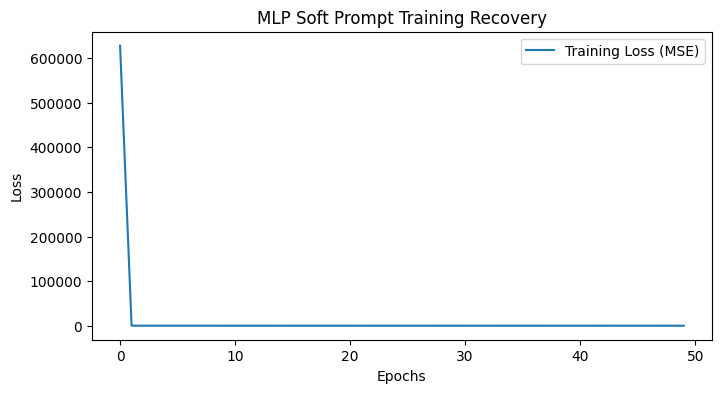

In [23]:
# > 呼叫 MLP 訓練腳本
from scripts.train_mlp import train_soft_prompt_mlp
import matplotlib.pyplot as plt

# 執行預訓練 (映射數值特徵到嵌入空間)
model, loss_history = train_soft_prompt_mlp(
    df_processed, 
    df_pca, 
    meta_path="data/spotify_meta.pkl", 
    epochs=50
)

# 視覺化訓練 Loss 曲線
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label="Training Loss (MSE)")
plt.title("MLP Soft Prompt Training Recovery")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 透過 MLP 將所有歌曲都轉為向量

In [42]:
# > 呼叫批次預測腳本
from scripts.batch_predict_embeddings import batch_generate_soft_prompts

# 使用微調後的模型產生所有歌曲的語義向量地圖',
soft_prompts_map = batch_generate_soft_prompts(
    df_processed,
    df_pca,
    model_path="data/soft_prompt_mlp_finetuned.pth",
    output_path="data/soft_prompts_map.pkl"
)

# 檢查成果',
sample_id = list(soft_prompts_map.keys())[0]
print(f"Sample Track ID: {sample_id}")
print(f"Vector Dimension: {len(soft_prompts_map[sample_id])}")

# > 引用模組化索引建置工具
from scripts.build_prediction_index import build_index_from_soft_prompts

# 正式建立 20,000 筆資料的全量預測索引
# 輸入: 
#   df: 包含歌曲詳細資訊的原始 DataFrame
#   soft_prompts_map: 您剛剛批次產出的 20,000 筆向量字典
full_index, faiss_metadata = build_index_from_soft_prompts(df, soft_prompts_map)

# 驗證同步狀態
print(f"// @ 狀態確認: 索引已更新至 data/spotify.index")


// > 已載入模型: data/soft_prompt_mlp_finetuned.pth，準備轉換 19900 首歌曲...
// > 正在提取特徵: PCA (18) + 原始數值 (15)
// > 正在進行批次預測 (Inference)...
// @ 語義向量字典建置完成！已存至: data/soft_prompts_map.pkl
   - 總歌曲數: 18863
Sample Track ID: 6KwkVtXm8OUp2XffN5k7lY
Vector Dimension: 384
// > 正在準備 18863 筆向量進行索引化...
// > 正在收集元數據對照表...
// > 正在儲存索引至 data/spotify.index...
// > 正在儲存元數據至 data/spotify_faiss_meta.pkl...
// @ 全量索引建置完成！共計 18863 筆資料已上線。
// @ 狀態確認: 索引已更新至 data/spotify.index


## 透過 [DATA 1 & 2] 訓練 MLP (Fine-tuning) (優選)

### 輸入(X): 偽共現關係 / 用戶畫像

### 目標(Y): 推薦歌曲

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: a6d44931-73b3-45f1-9d5c-548f363eb869)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].


// > 模型預期輸入維度: 33
// > 特徵查表已建立: 18863 筆獨特歌曲，維度: 33
// > 載入 RAG 文本字典以優化微調標籤: data/rag_docs.csv
// > 正在從 data/precomputed_similar_songs.json 讀取共現關係數據...
// @ [DATA 1] 加入了 2021 筆具備 RAG 描述的共現樣本。
// > 正在從 data/persona_listening_histories 收集畫像數據...
// @ [DATA 2] 加入了 11 筆具備 RAG 描述的畫像樣本。
// @ 總計收集到 2032 筆混合微調樣本 (X shape: (2032, 33))。
// > 開始對 Persona 進行模型微調...
   - Fine-tune Epoch [5/20], Loss: 6.968793, LR: 0.0001
   - Fine-tune Epoch [10/20], Loss: 1.908836, LR: 5e-05
   - Fine-tune Epoch [15/20], Loss: 0.271738, LR: 5e-05
   - Fine-tune Epoch [20/20], Loss: 0.560441, LR: 2.5e-05
// @ 微調完成並存至: data/soft_prompt_mlp_finetuned.pth


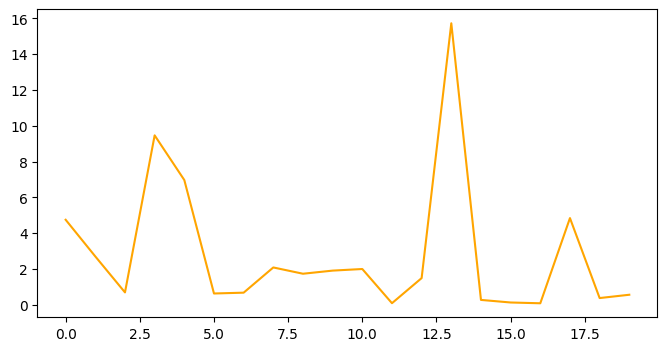

In [30]:
# > 呼叫 MLP 微調腳本
from scripts.finetune_mlp import finetune_soft_prompt_mlp

# 執行微調 (讓模型學會 Persona 的具體品味)
ft_model, ft_loss_history = finetune_soft_prompt_mlp(
    df_processed, 
    df_pca, 
    base_model_path="data/soft_prompt_mlp.pth", 
    output_path="data/soft_prompt_mlp_finetuned.pth", 
    epochs=20
)

# 視覺化微調 Loss 曲線
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(ft_loss_history, color="orange", label="Fine-tuning Loss")
# ... (顯示 Loss 曲線)


# 推薦流程

## 選擇 persona 並透過 MLP 轉成 Soft Prompt

In [31]:
# > 從畫像歷史中提取語義重心 (Soft Prompt)
from scripts.get_persona_prompt import get_persona_soft_prompt, list_available_personas

# 1. 列出可用的畫像
available_personas = list_available_personas()
print(f"Available Personas: {available_personas}")

# 2. 選擇一個畫像進行推薦模擬 (例如 Party Animal)
target_persona = "Party Animal"
if target_persona in available_personas:
    # 提取該畫像的平均預測向量 (Soft Prompt)
    persona_soft_prompt = get_persona_soft_prompt(target_persona, soft_prompts_map)
    
    print(f"\n--- {target_persona} Soft Prompt Summary ---")
    print(f"Vector Mean: {persona_soft_prompt.mean():.4f}")
    print(f"Vector Max: {persona_soft_prompt.max():.4f}")
else:
    print(f"Error: {target_persona} not found.")


Available Personas: ['Chill Vibes', 'Party Animal', 'Study Focus', 'Workout Motivation']
// @ 成功計算畫像 'Party Animal' 的 Soft Prompt
   - 引用歷史歌曲數: 20 / 20
   - 代表性歌曲: Badness, Iko Iko - From "Alvin And The Chipmunks: The Road Chip" Soundtrack, Na Boca do Litrão...

--- Party Animal Soft Prompt Summary ---
Vector Mean: -0.0019
Vector Max: 0.0500


## 隨機播放一首歌曲並透過 MLP 轉成 Soft Prompt

In [33]:
# > 隨機選一首「當前播放歌曲」並獲取其詳細資訊
import numpy as np

# 1. 隨機取一首歌曲 ID
current_song_id = np.random.choice(list(soft_prompts_map.keys()))

# 2. 直接從 df 查找詳細資訊 (確保 20,000 筆都能搜到)
# 這裡使用 df 而不是 metadata，因為 df 是原始 20,000 筆數據源
song_row = df[df['track_id'] == current_song_id].iloc[0]
current_song_details = song_row.to_dict()

# 3. 獲取該曲的 MLP 預測向量
current_song_soft_prompt = soft_prompts_map[current_song_id]

print(f"Current Playing: {current_song_details['track_name']} by {current_song_details['artists']}")
print(f"Current Song Vector Summary: Mean={current_song_soft_prompt.mean():.4f}")


Current Playing: Vossa Excelência by Titãs
Current Song Vector Summary: Mean=-0.0019


## 長期偏好總結搜尋

In [34]:
# > 讀取 LLM 產出的畫像文字總結 (來自 DATA 2)
import json
import os

summary_path = "data/persona_listening_histories/persona_summaries.json"
if os.path.exists(summary_path):
    with open(summary_path, "r", encoding="utf-8") as f:
        persona_summaries = json.load(f)
    current_persona_summary = persona_summaries.get(target_persona, "無特定偏好總結。")
    print(f"--- {target_persona} 長期偏好總結 ---")
    print(current_persona_summary)
else:
    print("尚未生成畫像總結。")


--- Party Animal 長期偏好總結 ---
1. **多元曲風喜好**：用戶的收聽清單涵蓋多種音樂風格，從工業音樂（Rammstein）到兒童音樂（Alvin & The Chipmunks、Koo Koo Kanga Roo）、電子音樂（deep-house、minimal-techno、trance）及流行音樂（BLACKPINK），顯示對多樣化音樂風格的接受度。

2. **偏好快節奏和舞曲元素**：選擇如j-dance、deep-house、minimal-techno和breakbeat的歌曲，顯示用戶對快節奏和舞曲節拍的偏好。

3. **喜歡派對和節慶氛圍**：如Jürgen Drews的派對音樂和Ara Ketu的sertanejo，暗示用戶對能夠激發節慶或派對氣氛的音樂有興趣。

4. **語言多樣性**：收聽西班牙語（Supersubmarina）、德語（Rammstein）、葡萄牙語（Zé Vaqueiro）的歌曲，顯示用戶對不同語言音樂的開放態度。

5. **輕鬆幽默元素**：選擇如Alvin & The Chipmunks和Koo


## 數值特徵檢索

In [35]:
# > 執行數值特徵檢索 (Numerical/Pre-computed Retrieval)
import json

# 從先前計算好的相似矩陣中獲取候選歌曲
current_song_sim_items = next((item for item in all_similar_songs if item["track_id"] == current_song_id), None)

numerical_candidates = []
if current_song_sim_items:
    # 獲取前 10 首相似歌曲
    numerical_candidates = current_song_sim_items.get('top_n_similar_songs', [])
    print(f"--- 數值特徵檢索結果 (基於原始歌曲) ---")
    for i, sim_song in enumerate(numerical_candidates):
        sim_val = sim_song.get('similarity_score', 0.0)
        # 檢查是否為數值，若是則格式化，否則直接印出
        sim_str = f"{sim_val:.4f}" if isinstance(sim_val, (int, float)) else "N/A"
        print(f"{i+1}. {sim_song['track_name']} by {sim_song['artists']} (Similarity: {sim_str})")
else:
    print("找不到當前歌曲的數值相似候選清單。")


--- 數值特徵檢索結果 (基於原始歌曲) ---
1. RATS - FROM "GIGS" CASE OF BOOWY by BOØWY (Similarity: 0.9670)
2. Cassandra by The Naked And The Dead (Similarity: 0.9610)
3. Drama by Carajo (Similarity: 0.9478)
4. Wake up Dead (feat. Dave Mustaine) by Lamb of God;Megadeth;Dave Mustaine (Similarity: 0.9456)
5. Hardwired by Metallica (Similarity: 0.9349)
6. Rakugakipeiji by KANKAKU PIERO (Similarity: 0.9334)
7. ブラッドサーキュレーター by ASIAN KUNG-FU GENERATION (Similarity: 0.9298)
8. Pulang by SATCF (Similarity: 0.9197)
9. Franz Weiss by Die Apokalyptischen Reiter (Similarity: 0.9195)
10. Cry Baby by Official HIGE DANdism (Similarity: 0.9184)


## 語義檢索

In [36]:
# > 執行語義檢索 (Semantic Retrieval via FAISS)
import faiss
import numpy as np

# 1. 準備查詢向量 (使用當前歌曲的 MLP 預測向量)
# 同時為了對齊 FAISS 維度，我們將其擴張為 (1, 384) 的 numpy array
query_vector = current_song_soft_prompt.reshape(1, -1).astype('float32')

# 2. 進行搜尋 (找前 10 名)
distances, indices = index.search(query_vector, k=11) # 多抓一個以防包含自己

semantic_candidates = []
print(f"--- 語義檢索結果 (基於 MLP 預測向量) ---")
for i, idx in enumerate(indices[0]):
    # 排除掉當前正在播放的歌曲本身
    if metadata[idx]['track_id'] == current_song_id:
        continue
    
    candidate = metadata[idx]
    semantic_candidates.append(candidate)
    
    # 僅顯示前 10 個
    if len(semantic_candidates) <= 10:
        print(f"{len(semantic_candidates)}. {candidate['track_name']} by {candidate['artists']} (Dist: {distances[0][i]:.4f})")


--- 語義檢索結果 (基於 MLP 預測向量) ---
1. Levitating by Dua Lipa (Dist: 1.0940)
2. Tu Eres La Que Amo by Salserin (Dist: 1.1019)
3. Apasionadamente by Maelo Ruiz (Dist: 1.1285)
4. Nadie Igual Que Tu by Maelo Ruiz (Dist: 1.1318)
5. No Soy Automático by Hector Tricoche (Dist: 1.1323)
6. Volvera by El Canto Del Loco (Dist: 1.1323)
7. Illusion by Max Brhon (Dist: 1.1365)
8. One More Coffee by Celestial Alignment (Dist: 1.1367)
9. Tendência - Ao vivo by Jorge Aragão (Dist: 1.1390)
10. Apatía - The Beautyscape Remix by Pitizion;Adso Alejandro;Andy Clay (Dist: 1.1396)


## 整合所有結果: [persona Soft Prompt] + [數值特徵檢索] + [語義檢索] 

In [39]:
# > 整合所有檢索結果並進行 Agentic Scoring
from scripts.recommender_agent import calculate_cosine_similarity

# 1. 建立去重清單
all_candidates_dict = {}

# 1.1 整合數值檢索 (Step 1)
for c in numerical_candidates:
    tid = c['track_id']
    # 修正查表：直接從全量 df 撈取，避免 metadata 長度不足問題
    rows = df[df['track_id'] == tid]
    if not rows.empty:
        all_candidates_dict[tid] = rows.iloc[0].to_dict()

# 1.2 整合語義檢索 (Step 2)
for c in semantic_candidates:
    all_candidates_dict[c['track_id']] = c

# 2. 計算與 Persona 的語義匹配度
final_candidate_list = []
for tid, meta in all_candidates_dict.items():
    # 確保這首歌有預測向量
    if tid in soft_prompts_map:
        # 計算此歌向量與「畫像重心向量」的相似度
        sim_score = calculate_cosine_similarity(persona_soft_prompt, soft_prompts_map[tid])
        
        meta_with_score = meta.copy()
        meta_with_score['persona_match_score'] = float(sim_score)
        
        # 標註來源，協助 LLM 推理
        source = "Semantic_Match" if tid in [sc['track_id'] for sc in semantic_candidates] else "Numerical_Match"
        meta_with_score['retrieval_source'] = source
        
        final_candidate_list.append(meta_with_score)

print(f"// @ 整合完成！共收集到 {len(final_candidate_list)} 首獨特候選歌曲，已準備好進行 AI 重排序。")
print(final_candidate_list)


// @ 整合完成！共收集到 21 首獨特候選歌曲，已準備好進行 AI 重排序。
[{'Unnamed: 0': 63542, 'track_id': '1RFTlrpmEUyBpkaW6mfrxQ', 'artists': 'BOØWY', 'album_name': '"GIGS" CASE OF BOφWY COMPLETE (Live From "Gigs" Case Of Boowy / 1987)', 'track_name': 'RATS - FROM "GIGS" CASE OF BOOWY', 'popularity': 34, 'duration_ms': 159600, 'explicit': False, 'danceability': 0.258, 'energy': 0.985, 'key': 0, 'loudness': -3.376, 'mode': 1, 'speechiness': 0.157, 'acousticness': 0.0202, 'instrumentalness': 0.000308, 'liveness': 0.432, 'valence': 0.382, 'tempo': 176.952, 'time_signature': 4, 'track_genre': 'j-rock', 'persona_match_score': 1.0000001192092896, 'retrieval_source': 'Numerical_Match'}, {'Unnamed: 0': 41611, 'track_id': '2zvAon77qSlqp1fWHyyFvR', 'artists': 'The Naked And The Dead', 'album_name': 'The Naked and the Dead', 'track_name': 'Cassandra', 'popularity': 22, 'duration_ms': 206160, 'explicit': False, 'danceability': 0.144, 'energy': 0.987, 'key': 0, 'loudness': -4.283, 'mode': 1, 'speechiness': 0.179, 'acousticness

## 代理人協作推理與重排序

In [40]:
# > 進行多模型 Agentic 推薦與品味對比
from scripts.recommender_agent import get_multi_model_recommendations, calculate_cosine_similarity

# 3. 啟動多模型並行推理 (會同時呼叫 GPT-4o, Gemini 2.0, Grok-2)
print(f"// > 正在為 {target_persona} 生成代理人推薦 (候選歌曲數: {len(final_candidate_list)})...")
multi_results, errors = get_multi_model_recommendations(
    target_persona, 
    current_song_details, 
    current_persona_summary, 
    final_candidate_list
)

# 4. 展示對比結果
if errors:
    print(f"部分模型執行錯誤: {errors}")

for model_name, result in multi_results.items():
    print(f"\n{'='*20} 🤖 {model_name} 推薦報告 {'='*20}")
    print(f"策略摘要: {result['agent_explanation']}\n")
    for i, rec in enumerate(result['recommendations']):
        print(f"   [{i+1}] {rec['track_name']} - {rec['artists']}")
        print(f"       💡 理由: {rec['reason']}")
    print("\n")


// > 正在為 Party Animal 生成代理人推薦 (候選歌曲數: 21)...
// > 正在請求 GPT-4o...
// > 正在請求 Gemini-2.0-Flash...
// > 正在請求 Grok 4.1 Fast...

==================== 🤖 Gemini-2.0-Flash 推薦報告 ====================
策略摘要: 基於用戶的多元曲風喜好和對快節奏、舞曲元素的偏好，我選擇了幾首高能量、快節奏的歌曲，涵蓋 Hard-Rock, Punk-Rock, Groove, Spanish 和 Pop 等風格，確保推薦的歌曲能夠激發用戶的派對氛圍，同時也過濾了 Explicit 內容。

   [1] Hardwired - Metallica
       💡 理由: Metallica 的 Hardwired 以其 186 BPM 的高速節奏和 Hard-Rock 風格，絕對能點燃你的派對熱情。
   [2] ブラッドサーキュレーター - ASIAN KUNG-FU GENERATION
       💡 理由: ASIAN KUNG-FU GENERATION 的這首 Punk-Rock 歌曲，能量高達 0.975，保證讓你活力四射。
   [3] Wake up Dead (feat. Dave Mustaine) - Lamb of God;Megadeth;Dave Mustaine
       💡 理由: Lamb of God 聯手 Megadeth 的 Groove 金曲，能量高達 0.937，絕對能讓你嗨翻全場。
   [4] Volvera - El Canto Del Loco
       💡 理由: El Canto Del Loco 的 Volvera 是一首充滿活力的 Spanish 歌曲，能量高達 0.892，非常適合跳舞。
   [5] Levitating - Dua Lipa
       💡 理由: Dua Lipa 的 Levitating 是一首流行的 Pop 歌曲，Danceability 高達 0.695，絕對能讓你隨著節奏舞動。



==================== 🤖 GPT-4o 推薦報告 ====================
策略摘要

## Embedding Space Visualization

In [ ]:
%run scripts/notebook_visualization.py